<a href="https://colab.research.google.com/github/RonM254/Healthcare-EDA/blob/main/Healthcare_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)

# data (as pandas dataframes)
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

# metadata
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata)

# variable information
print(diabetes_130_us_hospitals_for_years_1999_2008.variables)


/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

In [4]:
#Load the data
df = pd.read_csv('../data/raw/diabetes_data.csv')

print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())

print("\nColumn Names and Types:")
print(df.dtypes)

print("\nBasic Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))


/tmp/ipython-input-1304494347.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://archive.ics.uci.edu/static/public/296/data.csv')


Dataset Shape: (101766, 50)

First Few Rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   
3        500364     82442376        Caucasian    Male  [30-40)    NaN   
4         16680     42519267        Caucasian    Male  [40-50)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1 

In [5]:
# Replace '?' with NaN
df = df.replace('?', np.nan)

# Check missing values percentage
missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nMissing Value Percentages:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

# Drop columns with >40% missing values
cols_to_drop = missing_pct[missing_pct > 40].index
df = df.drop(columns=cols_to_drop)

# Remove duplicate patient encounters
df = df.drop_duplicates(subset=['patient_nbr'], keep='first')

# Convert numeric columns stored as objects
numeric_cols = ['admission_type_id', 'discharge_disposition_id',
                'admission_source_id']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"\nCleaned dataset shape: {df.shape}")


Missing Value Percentages:
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

Cleaned dataset shape: (71518, 46)


In [6]:
# Create age group categories
df['age_group'] = df['age'].replace({
    '[0-10)': '0-30', '[10-20)': '0-30', '[20-30)': '0-30',
    '[30-40)': '30-50', '[40-50)': '30-50',
    '[50-60)': '50-70', '[60-70)': '50-70',
    '[70-80)': '70+', '[80-90)': '70+', '[90-100)': '70+'
})

# Binary readmission target
df['readmitted_30days'] = (df['readmitted'] == '<30').astype(int)

# Length of stay category
df['time_in_hospital_cat'] = pd.cut(df['time_in_hospital'],
                                      bins=[0, 3, 7, 14],
                                      labels=['Short (1-3)', 'Medium (4-7)', 'Long (8-14)'])

# Number of medications flag
df['num_medications_cat'] = pd.cut(df['num_medications'],
                                     bins=[0, 10, 20, 100],
                                     labels=['Low (0-10)', 'Medium (11-20)', 'High (20+)'])

print("\nFeature Engineering Complete")
print(f"Readmission within 30 days: {df['readmitted_30days'].sum()} patients")


Feature Engineering Complete
Readmission within 30 days: 6293 patients


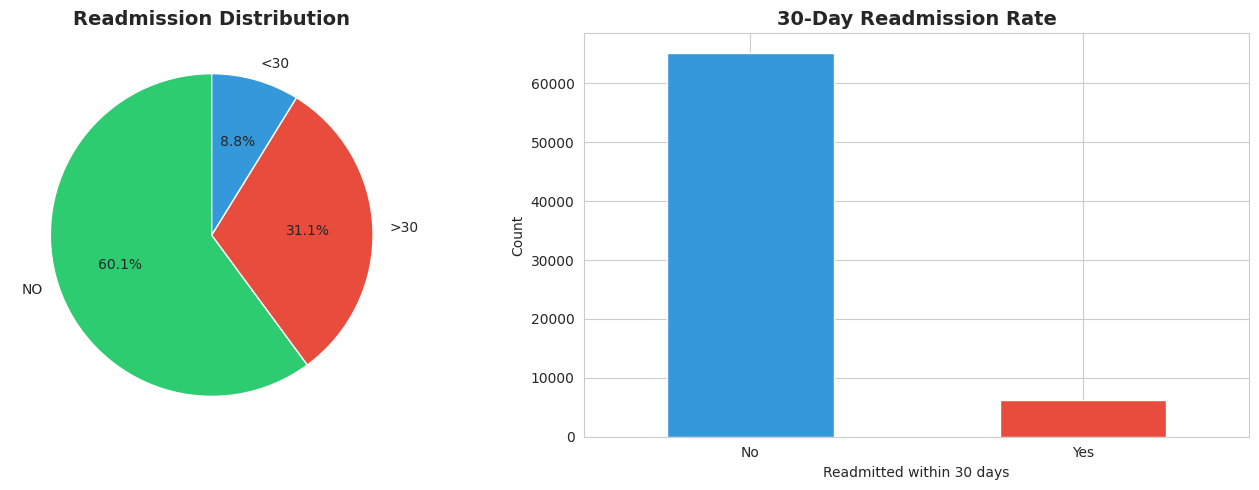

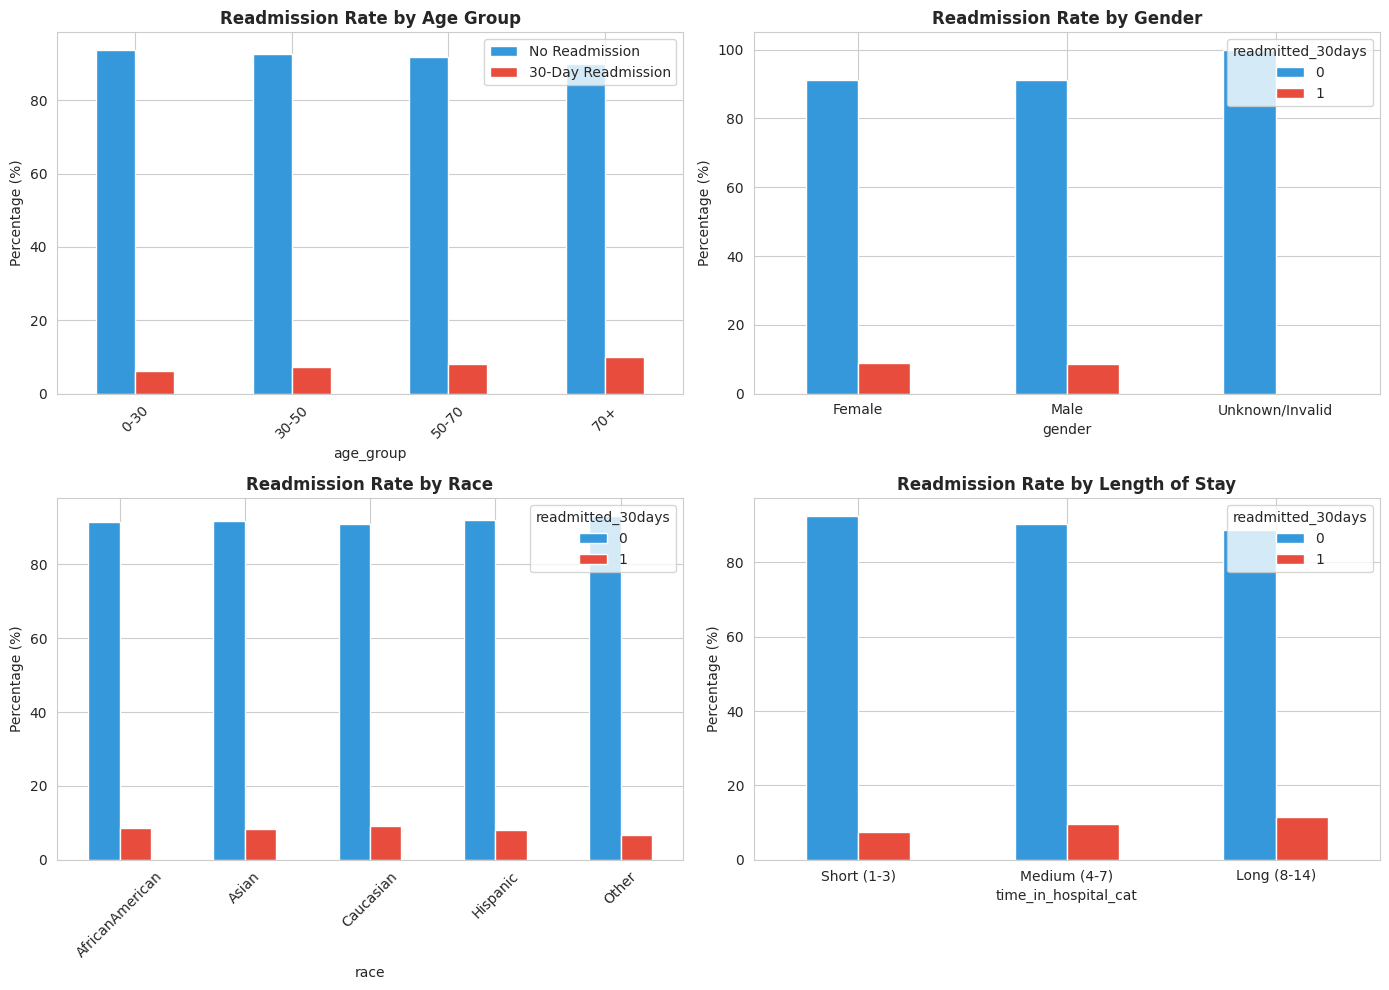

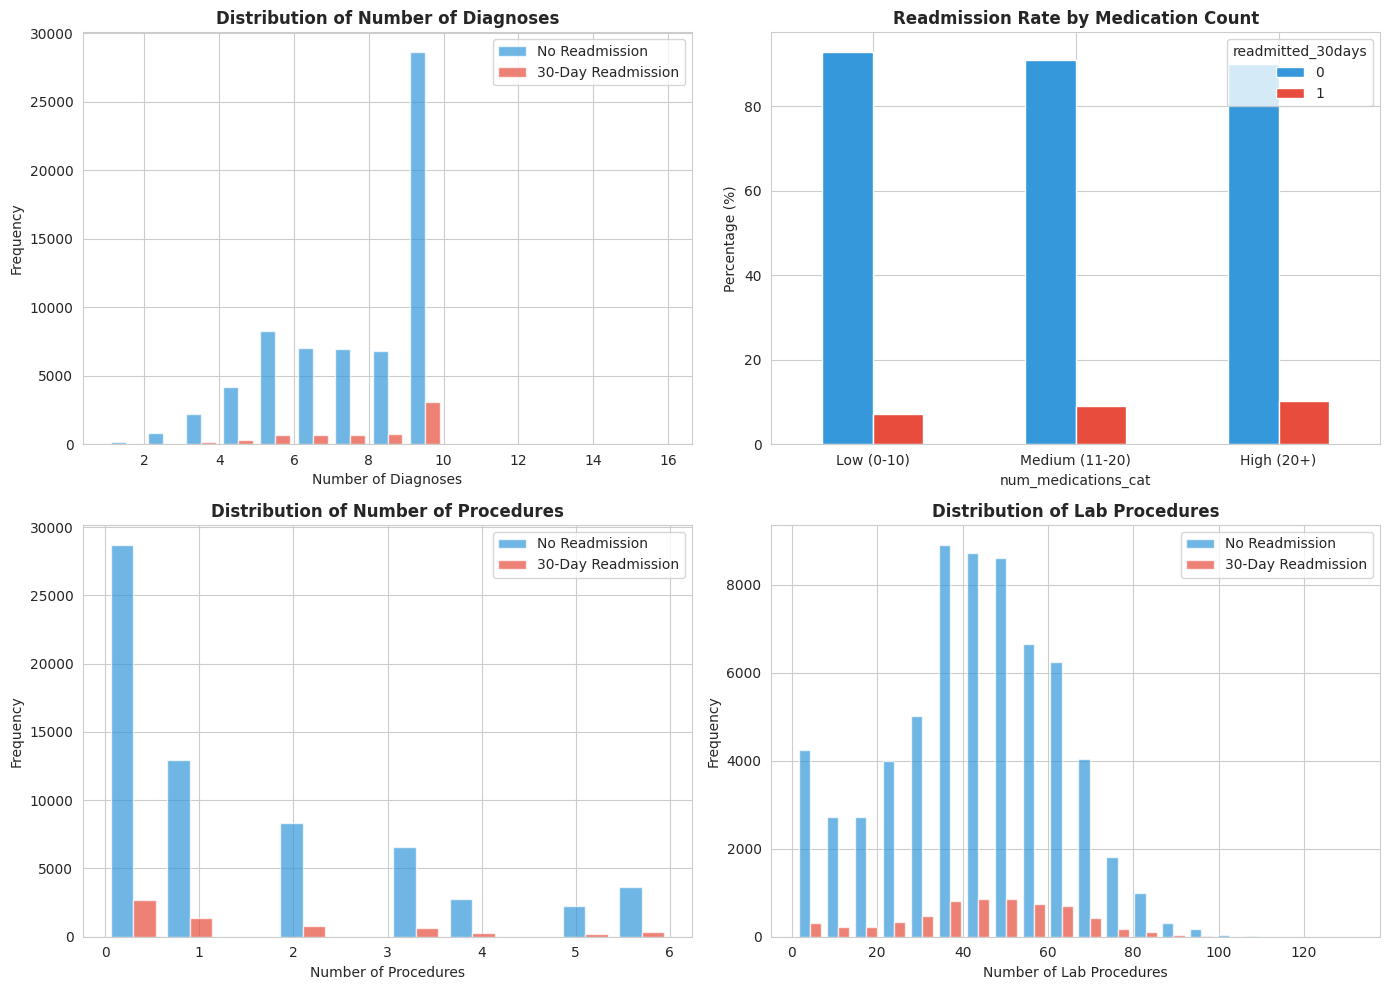

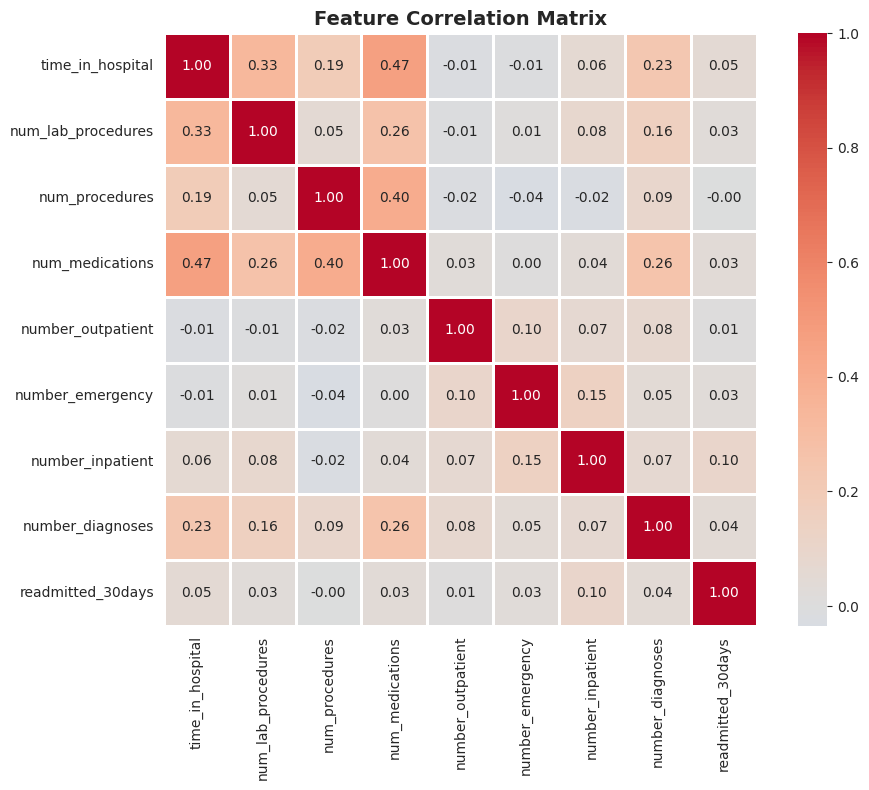

In [7]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Readmission Rate Overview
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

readmit_counts = df['readmitted'].value_counts()
axes[0].pie(readmit_counts, labels=readmit_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['#2ecc71', '#e74c3c', '#3498db'])
axes[0].set_title('Readmission Distribution', fontsize=14, fontweight='bold')

df['readmitted_30days'].value_counts().plot(kind='bar', ax=axes[1],
                                              color=['#3498db', '#e74c3c'])
axes[1].set_title('30-Day Readmission Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Readmitted within 30 days')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.savefig('readmission_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Demographics Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
age_readmit = pd.crosstab(df['age_group'], df['readmitted_30days'], normalize='index') * 100
age_readmit.plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c'])
axes[0, 0].set_title('Readmission Rate by Age Group', fontweight='bold')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].legend(['No Readmission', '30-Day Readmission'])
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)

# Gender distribution
gender_readmit = pd.crosstab(df['gender'], df['readmitted_30days'], normalize='index') * 100
gender_readmit.plot(kind='bar', ax=axes[0, 1], color=['#3498db', '#e74c3c'])
axes[0, 1].set_title('Readmission Rate by Gender', fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

# Race distribution
race_readmit = pd.crosstab(df['race'], df['readmitted_30days'], normalize='index') * 100
race_readmit.plot(kind='bar', ax=axes[1, 0], color=['#3498db', '#e74c3c'])
axes[1, 0].set_title('Readmission Rate by Race', fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

# Length of stay
los_readmit = pd.crosstab(df['time_in_hospital_cat'], df['readmitted_30days'], normalize='index') * 100
los_readmit.plot(kind='bar', ax=axes[1, 1], color=['#3498db', '#e74c3c'])
axes[1, 1].set_title('Readmission Rate by Length of Stay', fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('demographics_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Clinical Factors Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Number of diagnoses
axes[0, 0].hist([df[df['readmitted_30days']==0]['number_diagnoses'],
                  df[df['readmitted_30days']==1]['number_diagnoses']],
                 bins=15, label=['No Readmission', '30-Day Readmission'],
                 color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0, 0].set_title('Distribution of Number of Diagnoses', fontweight='bold')
axes[0, 0].set_xlabel('Number of Diagnoses')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Number of medications
med_readmit = pd.crosstab(df['num_medications_cat'], df['readmitted_30days'], normalize='index') * 100
med_readmit.plot(kind='bar', ax=axes[0, 1], color=['#3498db', '#e74c3c'])
axes[0, 1].set_title('Readmission Rate by Medication Count', fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

# Number of procedures
axes[1, 0].hist([df[df['readmitted_30days']==0]['num_procedures'],
                  df[df['readmitted_30days']==1]['num_procedures']],
                 bins=10, label=['No Readmission', '30-Day Readmission'],
                 color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1, 0].set_title('Distribution of Number of Procedures', fontweight='bold')
axes[1, 0].set_xlabel('Number of Procedures')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Number of lab procedures
axes[1, 1].hist([df[df['readmitted_30days']==0]['num_lab_procedures'],
                  df[df['readmitted_30days']==1]['num_lab_procedures']],
                 bins=20, label=['No Readmission', '30-Day Readmission'],
                 color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1, 1].set_title('Distribution of Lab Procedures', fontweight='bold')
axes[1, 1].set_xlabel('Number of Lab Procedures')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('clinical_factors.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Correlation Analysis
numeric_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                    'num_medications', 'number_outpatient', 'number_emergency',
                    'number_inpatient', 'number_diagnoses']

corr_matrix = df[numeric_features + ['readmitted_30days']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
print("\n" + "="*50)
print("KEY FINDINGS - STATISTICAL ANALYSIS")
print("="*50)

# Overall readmission rate
readmit_rate = (df['readmitted_30days'].sum() / len(df)) * 100
print(f"\n1. Overall 30-day readmission rate: {readmit_rate:.2f}%")

# Age group analysis
print("\n2. Readmission rates by age group:")
age_stats = df.groupby('age_group')['readmitted_30days'].agg(['mean', 'count'])
age_stats['mean'] = age_stats['mean'] * 100
print(age_stats.round(2))

# Length of stay impact
print("\n3. Average length of stay:")
print(f"   - Readmitted patients: {df[df['readmitted_30days']==1]['time_in_hospital'].mean():.2f} days")
print(f"   - Not readmitted: {df[df['readmitted_30days']==0]['time_in_hospital'].mean():.2f} days")

# Statistical test
t_stat, p_value = stats.ttest_ind(
    df[df['readmitted_30days']==1]['time_in_hospital'],
    df[df['readmitted_30days']==0]['time_in_hospital']
)
print(f"   - T-test p-value: {p_value:.4f} {'(Significant)' if p_value < 0.05 else '(Not significant)'}")

# Number of medications
print("\n4. Medication analysis:")
print(f"   - Avg medications (readmitted): {df[df['readmitted_30days']==1]['num_medications'].mean():.2f}")
print(f"   - Avg medications (not readmitted): {df[df['readmitted_30days']==0]['num_medications'].mean():.2f}")

# Prior visits impact
print("\n5. Impact of prior hospital visits:")
print(f"   - Patients with prior inpatient visits readmission rate: {(df[df['number_inpatient']>0]['readmitted_30days'].mean()*100):.2f}%")
print(f"   - Patients with no prior visits readmission rate: {(df[df['number_inpatient']==0]['readmitted_30days'].mean()*100):.2f}%")

# High-risk profile
print("\n6. High-risk patient profile:")
high_risk = df[
    (df['number_inpatient'] > 0) &
    (df['number_emergency'] > 0) &
    (df['num_medications'] > 15)
]
print(f"   - Patients meeting high-risk criteria: {len(high_risk)}")
print(f"   - Readmission rate for high-risk: {(high_risk['readmitted_30days'].mean()*100):.2f}%")

print("\n" + "="*50)
print("Analysis complete! Check saved visualizations.")
print("="*50)


KEY FINDINGS - STATISTICAL ANALYSIS

1. Overall 30-day readmission rate: 8.80%

2. Readmission rates by age group:
            mean  count
age_group              
0-30        6.17   1816
30-50       7.26   9577
50-70       8.07  28426
70+        10.07  31699

3. Average length of stay:
   - Readmitted patients: 4.80 days
   - Not readmitted: 4.24 days
   - T-test p-value: 0.0000 (Significant)

4. Medication analysis:
   - Avg medications (readmitted): 16.62
   - Avg medications (not readmitted): 15.62

5. Impact of prior hospital visits:
   - Patients with prior inpatient visits readmission rate: 15.02%
   - Patients with no prior visits readmission rate: 7.97%

6. High-risk patient profile:
   - Patients meeting high-risk criteria: 764
   - Readmission rate for high-risk: 18.19%

Analysis complete! Check saved visualizations.
